## Dataset Preparation Requirements

To create the preprocessed dataset, the following requirements must be met **before running the notebook**.

### 1. Required Folders

You must have:

- **`MIRACL-VC1_all_in_one`**  
  This folder contains the original MIRACL-VC1 dataset and will be used as the **input root**.

- **`PREPROCESSED_DATA`**  
  An **empty folder** that will be used as the **output root**, where the newly created preprocessed dataset will be saved.

These two paths must be correctly specified in the **third notebook cell** as `INPUT_ROOT` and `OUTPUT_ROOT`.

Example:
```python
# CHANGE THESE
INPUT_ROOT  = Path("your_MIRACL-VC1_all_in_one_path_here")
OUTPUT_ROOT = Path("the_empty_folder")


### 2. Python Environment

This project requires a **virtual environment** configured with:

- **Python 3.10.19**

⚠️ **Important**  
More recent Python versions are **not supported**, as they are incompatible with the required MediaPipe version used in this project.


In [8]:

%pip install "mediapipe==0.10.21"



In [9]:
import mediapipe as mp
print(mp.__version__)
print(hasattr(mp, "solutions"))


0.10.21
True


## NOW THAT MEDIAPIPE IS INSTALLED, PROCEED WITH THE REST OF THE NOTEBOOK ##

In [10]:
import os
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

import mediapipe as mp


In [11]:
# CHANGE THESE
INPUT_ROOT  = Path("C:/Users/ricca/Desktop/DATA SCIENCE/LIP READING PROJECT/MIRACL-VC1_all_in_one")
OUTPUT_ROOT = Path("C:/Users/ricca/Desktop/GitHub/Lip-Reading/PREPROCESSED DATA")  # new dataset root


In [12]:
mp_face_mesh = mp.solutions.face_mesh

# FACEMESH_LIPS is a set of landmark index pairs (connections).
LIP_CONNECTIONS = mp_face_mesh.FACEMESH_LIPS
MOUTH_LANDMARKS = sorted({idx for edge in LIP_CONNECTIONS for idx in edge})

len(MOUTH_LANDMARKS), MOUTH_LANDMARKS[:10], MOUTH_LANDMARKS[-10:]


(40,
 [0, 13, 14, 17, 37, 39, 40, 61, 78, 80],
 [314, 317, 318, 321, 324, 375, 402, 405, 409, 415])

In [13]:
def crop_mouth_64_rgb(
    bgr_img: np.ndarray,
    face_mesh,
    margin: float = 0.2,
    min_size: int = 5,
    up: int = 3
):
    """
    Input:
        bgr_img : np.ndarray (H,W,3) BGR image
    Output:
        np.ndarray (64,64,3) uint8 BGR mouth crop
        OR None if crop fails
    """

    def _fail(code: str, reason: str, **details):
        crop_mouth_64_rgb.last_fail_code = code
        crop_mouth_64_rgb.last_fail_reason = reason
        crop_mouth_64_rgb.last_fail_details = details
        return None

    crop_mouth_64_rgb.last_fail_code = None
    crop_mouth_64_rgb.last_fail_reason = None
    crop_mouth_64_rgb.last_fail_details = {}

    if bgr_img is None:
        return _fail("BGR_NONE", "bgr_img is None (e.g., frame read failed).")

    if not isinstance(bgr_img, np.ndarray):
        return _fail("BGR_NOT_NDARRAY", "bgr_img is not a numpy array.", type=str(type(bgr_img)))

    if len(bgr_img.shape) != 3 or bgr_img.shape[2] != 3:
        return _fail("BGR_BAD_SHAPE", "bgr_img must have shape (H,W,3).", shape=tuple(getattr(bgr_img, "shape", ())))

    h, w = bgr_img.shape[:2]
    if h <= 0 or w <= 0:
        return _fail("BGR_EMPTY", "bgr_img has non-positive dimensions.", h=int(h), w=int(w))

    if up is None or up <= 0:
        return _fail("BAD_UP", "up must be a positive integer.", up=up)

    try:
        big = cv2.resize(bgr_img, (w * up, h * up), interpolation=cv2.INTER_LINEAR)
    except Exception as e:
        return _fail("UPSAMPLE_ERROR", "cv2.resize failed during upsample.", error=str(e), h=int(h), w=int(w), up=int(up))

    H, W = big.shape[:2]
    if H <= 0 or W <= 0:
        return _fail("UPSAMPLE_EMPTY", "Upsampled image has non-positive dimensions.", H=int(H), W=int(W))

    try:
        rgb = cv2.cvtColor(big, cv2.COLOR_BGR2RGB)
    except Exception as e:
        return _fail("BGR2RGB_ERROR", "cv2.cvtColor failed converting BGR->RGB.", error=str(e), big_shape=tuple(big.shape))

    try:
        res = face_mesh.process(rgb)
    except Exception as e:
        return _fail("FACEMESH_PROCESS_ERROR", "face_mesh.process raised an exception.", error=str(e), rgb_shape=tuple(rgb.shape))

    if not getattr(res, "multi_face_landmarks", None):
        return _fail("NO_FACE", "No face landmarks detected by FaceMesh.", up=int(up), H=int(H), W=int(W))

    try:
        lm = res.multi_face_landmarks[0].landmark
    except Exception as e:
        return _fail("LANDMARK_ACCESS_ERROR", "Could not access landmarks from FaceMesh result.", error=str(e))

    try:
        _ = iter(MOUTH_LANDMARKS)
    except Exception as e:
        return _fail("MOUTH_LANDMARKS_INVALID", "MOUTH_LANDMARKS is not iterable or not defined.", error=str(e))

    xs, ys = [], []
    try:
        for i in MOUTH_LANDMARKS:
            xs.append(int(lm[i].x * W))
            ys.append(int(lm[i].y * H))
    except Exception as e:
        return _fail("MOUTH_INDEX_ERROR", "Failed while converting mouth landmarks to pixel coords.", error=str(e), num_landmarks=len(lm) if hasattr(lm, "__len__") else None, W=int(W), H=int(H))

    if len(xs) == 0 or len(ys) == 0:
        return _fail("NO_MOUTH_POINTS", "No mouth points were produced.", mouth_len=0)

    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)

    bw, bh = x2 - x1, y2 - y1
    if bw < min_size or bh < min_size:
        return _fail("MOUTH_TOO_SMALL", "Mouth bbox too small (likely bad detection or tiny face).", bw=int(bw), bh=int(bh), min_size=int(min_size), x1=int(x1), x2=int(x2), y1=int(y1), y2=int(y2))

    mx = int(bw * margin)
    my = int(bh * margin)

    x1m = max(0, x1 - mx)
    x2m = min(W, x2 + mx)
    y1m = max(0, y1 - my)
    y2m = min(H, y2 + my)

    if x2m <= x1m or y2m <= y1m:
        return _fail("MARGIN_DEGENERATE_UP", "BBox became degenerate after adding margin on upsampled image.", x1=int(x1), x2=int(x2), y1=int(y1), y2=int(y2), mx=int(mx), my=int(my), x1m=int(x1m), x2m=int(x2m), y1m=int(y1m), y2m=int(y2m), W=int(W), H=int(H))

    x1o = max(0, int(x1m / up))
    x2o = min(w, int(x2m / up))
    y1o = max(0, int(y1m / up))
    y2o = min(h, int(y2m / up))

    if x2o <= x1o or y2o <= y1o:
        return _fail("DEGENERATE_ORIG", "BBox became degenerate after mapping back to original resolution.", up=int(up), x1m=int(x1m), x2m=int(x2m), y1m=int(y1m), y2m=int(y2m), x1o=int(x1o), x2o=int(x2o), y1o=int(y1o), y2o=int(y2o), w=int(w), h=int(h))

    crop = bgr_img[y1o:y2o, x1o:x2o]
    if crop.size == 0:
        return _fail("CROP_EMPTY", "Crop slice produced an empty array.", x1=int(x1o), x2=int(x2o), y1=int(y1o), y2=int(y2o), w=int(w), h=int(h))

    # ── resize to 64×64, keeping all 3 BGR channels ──────────────────────────
    try:
        crop64 = cv2.resize(crop, (64, 64), interpolation=cv2.INTER_AREA)
    except Exception as e:
        return _fail("RESIZE64_ERROR", "cv2.resize failed resizing to 64x64.", error=str(e), crop_shape=tuple(crop.shape))

    return crop64  # shape: (64, 64, 3), dtype: uint8, color space: BGR


In [14]:
IMG_EXTS = {".jpg", ".jpeg"}

def list_word_images(input_root: Path):
    paths = []
    # Typical structure: <PersonID>/(words|phrases)/<word_id>/<instance_id>/...images...
    for person_dir in sorted([p for p in input_root.iterdir() if p.is_dir()]):
        words_dir = person_dir / "words"
        if not words_dir.exists():
            continue

        for p in words_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                paths.append(p)

    return paths

word_image_paths = list_word_images(INPUT_ROOT)
len(word_image_paths), (word_image_paths[0] if word_image_paths else None)


(15494,
 WindowsPath('C:/Users/ricca/Desktop/DATA SCIENCE/LIP READING PROJECT/MIRACL-VC1_all_in_one/F01/words/01/01/color_001.jpg'))

In [15]:
# MediaPipe FaceMesh setup
# static_image_mode=True is best for processing individual images (not video tracking)
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,       # better lip/eye landmarks
    min_detection_confidence=0.4
)

In [16]:

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

failed = []
skipped_not_color = 0
processed = 0

from collections import Counter
fail_counts = Counter()

def center_crop_bgr(bgr, frac=0.8):
    h, w = bgr.shape[:2]
    ch, cw = int(h * frac), int(w * frac)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    y2 = y1 + ch
    x2 = x1 + cw
    return bgr[y1:y2, x1:x2], (x1, y1)  # crop + offset



for in_path in tqdm(word_image_paths, desc="Cropping mouths (words only)"):
    # Read image
    bgr = cv2.imread(str(in_path), cv2.IMREAD_COLOR)
    # cv2.imread(..., IMREAD_COLOR) always returns 3-channel if it can read it,
    # BUT it returns None if unreadable. Also, we still guard for safety.
    if bgr is None:
        failed.append((str(in_path), "unreadable"))
        continue
    if len(bgr.shape) != 3 or bgr.shape[2] != 3:
        skipped_not_color += 1
        continue

    mouth64 = crop_mouth_64_rgb(bgr, face_mesh=face_mesh)
    if mouth64 is None and crop_mouth_64_rgb.last_fail_code == "NO_FACE":
        bgr_center, _ = center_crop_bgr(bgr, frac=0.8)
        mouth64 = crop_mouth_64_rgb(bgr_center, face_mesh=face_mesh)


    if mouth64 is None:
        code = crop_mouth_64_rgb.last_fail_code or "UNKNOWN"
        fail_counts[code] += 1
        failed.append((str(in_path), code, crop_mouth_64_rgb.last_fail_reason))
        continue


    # Mirror structure into output root
    rel = in_path.relative_to(INPUT_ROOT)
    out_path = (OUTPUT_ROOT / rel).with_suffix(".png")  # force PNG
    out_path.parent.mkdir(parents=True, exist_ok=True)

    ok = cv2.imwrite(str(out_path), mouth64)
    if not ok:
        failed.append((str(in_path), "write_failed"))
        continue

    processed += 1

face_mesh.close()

processed, skipped_not_color, len(failed)

print('most common failures:', fail_counts.most_common(20))



Cropping mouths (words only): 100%|██████████| 15494/15494 [07:01<00:00, 36.77it/s]

most common failures: []


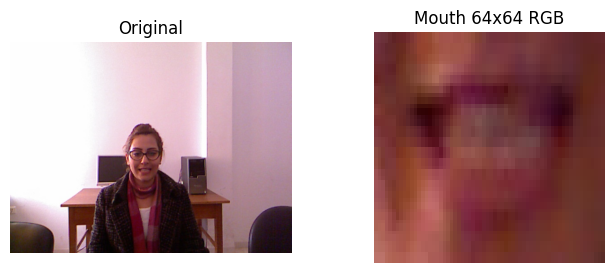

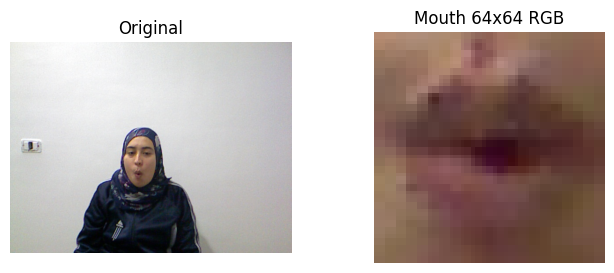

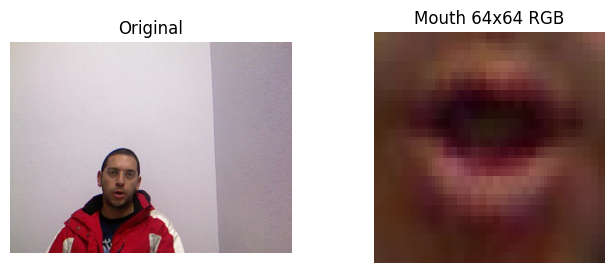

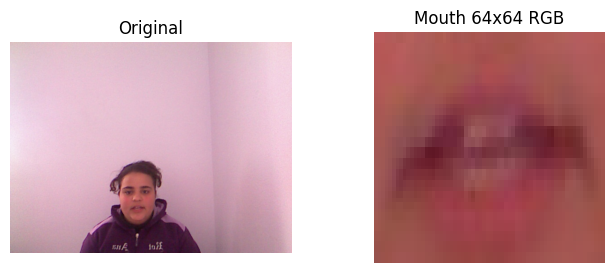

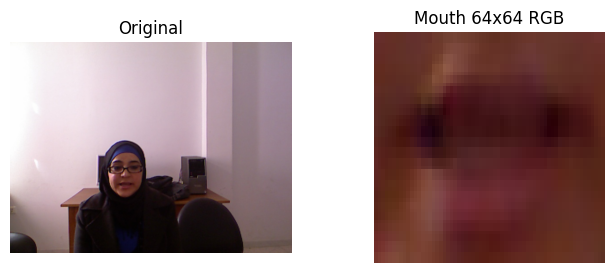

In [22]:
import random
import matplotlib.pyplot as plt

# Pick a few successful crops by checking existence in the output folder
samples = []
for _ in range(50):
    p = random.choice(word_image_paths)
    rel = p.relative_to(INPUT_ROOT)
    outp = (OUTPUT_ROOT / rel).with_suffix(".png")
    if outp.exists():
        samples.append((p, outp))
    if len(samples) >= 5:
        break

for in_p, out_p in samples:
    bgr = cv2.imread(str(in_p), cv2.IMREAD_COLOR)
    crop64 = cv2.imread(str(out_p), cv2.IMREAD_COLOR)  # load as BGR (3-channel)

    rgb_orig = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_crop = cv2.cvtColor(crop64, cv2.COLOR_BGR2RGB)  # convert crop for matplotlib

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.axis("off")
    plt.imshow(rgb_orig)

    plt.subplot(1, 2, 2)
    plt.title("Mouth 64x64 RGB")
    plt.axis("off")
    plt.imshow(rgb_crop)

    plt.show()


In [27]:
from pathlib import Path

# 🔧 SET THE PATH TO THE NEW (PREPROCESSED) DATASET HERE
DATASET_ROOT = Path("C:/Users/ricca/Desktop/GitHub/Lip-Reading/PREPROCESSED DATA")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

count = 0
for p in DATASET_ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXTS:
        count += 1

print("Total images in new CROPPED dataset:", count)


Total images in new CROPPED dataset: 15494


#### OUTPUT FORMAT

In [29]:
# Statistics
total = 0
failed_read = 0
channel_counts = Counter()
shape_counts = Counter()
dtype_counts = Counter()
size_set = set()

examples = defaultdict(list)  # for concrete examples per shape

for p in DATASET_ROOT.rglob("*"):
    if not (p.is_file() and p.suffix.lower() in IMG_EXTS):
        continue

    total += 1
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)

    if img is None:
        failed_read += 1
        continue

    dtype_counts[str(img.dtype)] += 1

    if img.ndim == 2:
        channel_counts["grayscale (1 channel)"] += 1
        h, w = img.shape
        c = 1
    elif img.ndim == 3:
        h, w, c = img.shape
        channel_counts[f"{c} channels"] += 1
    else:
        channel_counts["unknown format"] += 1
        continue

    shape_counts[(h, w, c)] += 1
    size_set.add((h, w))

    if len(examples[(h, w, c)]) < 3:
        examples[(h, w, c)].append(p)

# ====== REPORT ======
print("\n====== DATASET FORMAT CHECK ======")
print(f"Total image files found: {total}")
print(f"Unreadable images (cv2.imread failed): {failed_read}")

print("\n--- Channel distribution ---")
for k, v in channel_counts.most_common():
    print(f"{k}: {v}")

print("\n--- Image shapes (H, W, C) ---")
for k, v in shape_counts.most_common(10):
    print(f"{k}: {v}")

print("\n--- Dtypes ---")
for k, v in dtype_counts.items():
    print(f"{k}: {v}")

print("\n--- Unique sizes (H, W) ---")
print(sorted(size_set))



====== DATASET FORMAT CHECK ======
Total image files found: 15494
Unreadable images (cv2.imread failed): 0

--- Channel distribution ---
3 channels: 15494

--- Image shapes (H, W, C) ---
(64, 64, 3): 15494

--- Dtypes ---
uint8: 15494

--- Unique sizes (H, W) ---
[(64, 64)]
